***Question 4: Which hospitals are sitting on the biggest untapped opportunity?***

In [15]:
import pandas as pd
import numpy as np

aff = pd.read_csv("affiliation.csv")
alerts = pd.read_csv("alerts1.csv")
sales = pd.read_csv("sales.csv")

# bring in account info via HCP_ID
alerts_acc = pd.merge(alerts, aff, on='HCP_ID', how='inner')
sales_acc = pd.merge(sales, aff, on='HCP_ID', how='inner')

print(alerts_acc.shape, sales_acc.shape)

# ---- Q4: conversion ratio per account ----

alerts_by_acc = alerts_acc.groupby(['Account_ID', 'Account_Name']).size().reset_index(name='Total Alerts')

# DRG001 = our drug
our_rx_by_acc = sales_acc[sales_acc['Drug_ID'] == 'DRG001'].groupby('Account_ID').size().reset_index(name='Our Drug Prescription Count')

q4 = pd.merge(alerts_by_acc, our_rx_by_acc, on='Account_ID', how='left').fillna(0)
q4['Conversion Ratio'] = q4['Our Drug Prescription Count'] / q4['Total Alerts']

# top 10 alert accounts, worst converters first
top10_q4 = q4.sort_values('Total Alerts', ascending=False).head(10)
top10_q4 = top10_q4.sort_values('Conversion Ratio')

print("Q4 - top 10 accounts by alert volume, sorted by lowest conversion ratio")
print(top10_q4)






(9306, 6) (5808, 8)
Q4 - top 10 accounts by alert volume, sorted by lowest conversion ratio
   Account_ID                   Account_Name  Total Alerts  \
0      ACC001     Northside General Hospital          3296   
2      ACC003        Riverside Health System          1195   
1      ACC002        Eastview Medical Center          2350   
3      ACC004        Metro Regional Hospital           530   
4      ACC005        Lakewood Medical Center           585   
5      ACC006    Central University Hospital           493   
11     ACC012  Greenfield Medical Associates            85   
8      ACC009           Sunset Medical Group           100   
6      ACC007             Pinecrest Hospital           114   
9      ACC010         Valley Health Partners            92   

    Our Drug Prescription Count  Conversion Ratio  
0                         385.0          0.116808  
2                         159.0          0.133054  
1                         373.0          0.158723  
3                

***Question 5: Which accounts represent the largest untappedd prescription opportunity?***

In [ ]:
# ---- Q5: rx volume per active doctor ----

docs_by_acc = aff.groupby(['Account_ID', 'Account_Name'])['HCP_ID'].nunique().reset_index(name='# Affiliated Doctors')

active_docs_by_acc = sales_acc[sales_acc['Drug_ID'] == 'DRG001'].groupby('Account_ID')['HCP_ID'].nunique().reset_index(name='# Active Doctors')

vol_by_acc = sales_acc[sales_acc['Drug_ID'] == 'DRG001'].groupby('Account_ID')['Prescription_Volume'].sum().reset_index(name='Our Drug Prescription Volume')

q5 = pd.merge(docs_by_acc, active_docs_by_acc, on='Account_ID', how='left').fillna(0)
q5 = pd.merge(q5, vol_by_acc, on='Account_ID', how='left').fillna(0)

# avoid div by zero where no active docs
q5['Prescription Volume per Active Doctor'] = np.where(
    q5['# Active Doctors'] > 0,
    q5['Our Drug Prescription Volume'] / q5['# Active Doctors'],
    0
)

top10_q5 = q5.sort_values('Prescription Volume per Active Doctor').head(10)

print()
print("Q5 - bottom 10 accounts by rx volume per active doctor")
print(top10_q5)




Q5 - bottom 10 accounts by rx volume per active doctor
   Account_ID                   Account_Name  # Affiliated Doctors  \
21     ACC022        Ashwood Family Practice                     2   
16     ACC017               Maplewood Clinic                     3   
14     ACC015  Ridgecrest Community Hospital                     8   
11     ACC012  Greenfield Medical Associates                    10   
8      ACC009           Sunset Medical Group                    11   
2      ACC003        Riverside Health System                    24   
17     ACC018            Cedar Point Medical                     4   
3      ACC004        Metro Regional Hospital                    17   
7      ACC008              Harborview Clinic                     7   
13     ACC014       Clearwater Health Center                     6   

    # Active Doctors  Our Drug Prescription Volume  \
21               0.0                           0.0   
16               1.0                          59.0   
14         

***Scatter plot comparing account size vs prescriptions-per-active-doctor ratio, highlighting potential underperforming accounts***

   Account_ID                   Account_Name  Total_Doctors  Active_Doctors  \
21     ACC022        Ashwood Family Practice              2             0.0   
16     ACC017               Maplewood Clinic              3             1.0   
14     ACC015  Ridgecrest Community Hospital              8             7.0   
11     ACC012  Greenfield Medical Associates             10             7.0   
8      ACC009           Sunset Medical Group             11            10.0   
2      ACC003        Riverside Health System             24            15.0   
17     ACC018            Cedar Point Medical              4             3.0   
3      ACC004        Metro Regional Hospital             17            13.0   
7      ACC008              Harborview Clinic              7             6.0   
13     ACC014       Clearwater Health Center              6             6.0   

    Our_Drug_Volume  Prescriptions_per_Active_Doctor  
21              0.0                         0.000000  
16             59.0 

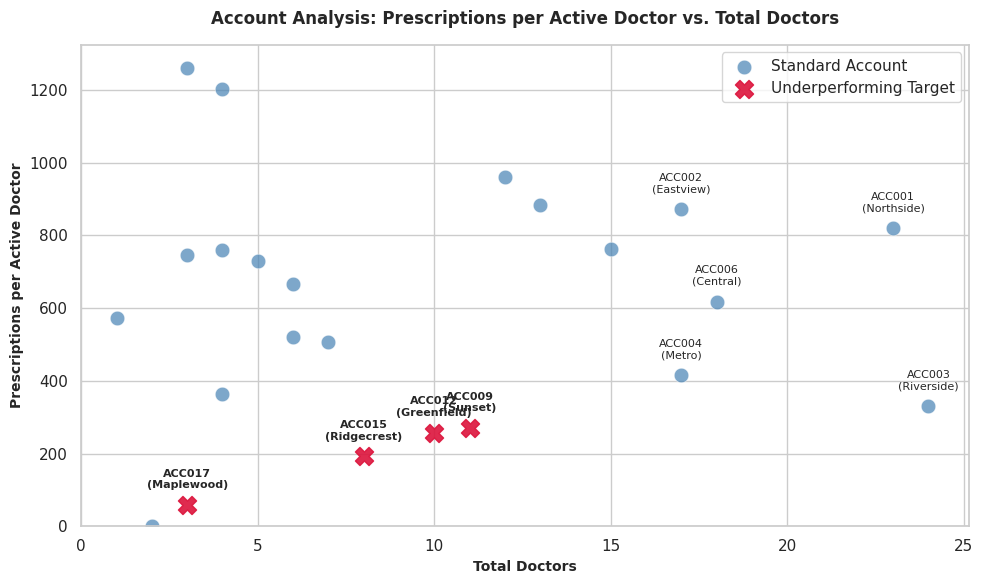

flagged accounts: ['ACC009', 'ACC012', 'ACC015', 'ACC017']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


aff = pd.read_csv("affiliation.csv")
sales = pd.read_csv("sales.csv")

# get total doctors per account
acc_size = aff.groupby(['Account_ID', 'Account_Name'])['HCP_ID'].nunique().reset_index(name='Total_Doctors')

# filter to our drug only
our_sales = sales.query("Drug_ID == 'DRG001'")
sales_acc = our_sales.merge(aff[['HCP_ID', 'Account_ID']], on='HCP_ID', how='inner')

# active doctors + volume per account
grouped = sales_acc.groupby('Account_ID').agg(
    Active_Doctors=('HCP_ID', 'nunique'),
    Our_Drug_Volume=('Prescription_Volume', 'sum')
).reset_index()

# combine into one account-level table
acc_summary = acc_size.merge(grouped, on='Account_ID', how='left')
acc_summary[['Active_Doctors', 'Our_Drug_Volume']] = acc_summary[['Active_Doctors', 'Our_Drug_Volume']].fillna(0)

def get_efficiency(row):
    if row['Active_Doctors'] == 0:
        return 0
    return row['Our_Drug_Volume'] / row['Active_Doctors']

acc_summary['Prescriptions_per_Active_Doctor'] = acc_summary.apply(get_efficiency, axis=1)

print(acc_summary.sort_values('Prescriptions_per_Active_Doctor').head(10))

has_writers = acc_summary[acc_summary['Active_Doctors'] > 0]
cutoff = has_writers['Prescriptions_per_Active_Doctor'].quantile(0.15)

flagged_ids = has_writers[has_writers['Prescriptions_per_Active_Doctor'] <= cutoff]['Account_ID'].tolist()

# cap it at 5 accounts so we're not flagging too many
if len(flagged_ids) > 5:
    flagged_ids = has_writers.nsmallest(5, 'Prescriptions_per_Active_Doctor')['Account_ID'].tolist()

acc_summary['is_flagged'] = acc_summary['Account_ID'].isin(flagged_ids)


sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# plot flagged accounts vs everyone else
for flagged, group in acc_summary.groupby('is_flagged'):
    if flagged:
        ax.scatter(group['Total_Doctors'], group['Prescriptions_per_Active_Doctor'],
                   color='crimson', s=170, marker='X', alpha=0.9, label='Underperforming Target')
    else:
        ax.scatter(group['Total_Doctors'], group['Prescriptions_per_Active_Doctor'],
                   color='steelblue', s=110, alpha=0.7, edgecolors='white', linewidth=0.5, label='Standard Account')

# label flagged accounts and any big accounts (>15 doctors)
big_account_cutoff = 15
for _, row in acc_summary.iterrows():
    if row['is_flagged'] or row['Total_Doctors'] > big_account_cutoff:
        short_name = row['Account_Name'].split()[0]
        ax.annotate(f"{row['Account_ID']}\n({short_name})",
                    xy=(row['Total_Doctors'], row['Prescriptions_per_Active_Doctor']),
                    xytext=(0, 12), textcoords='offset points',
                    ha='center', fontsize=8,
                    weight='bold' if row['is_flagged'] else 'normal')


ax.set_title('Account Analysis: Prescriptions per Active Doctor vs. Total Doctors', fontsize=12, pad=15, weight='bold')
ax.set_xlabel('Total Doctors', fontsize=10, weight='bold')
ax.set_ylabel('Prescriptions per Active Doctor', fontsize=10, weight='bold')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.legend(loc='upper right')

fig.tight_layout()
fig.savefig('account_efficiency_scatter.png', dpi=300)
plt.show()

print("flagged accounts:", flagged_ids)

***Q5 add-on: ranking by opportunity size instead of ratio***



In [ ]:
import pandas as pd
import numpy as np
pd.options.mode.chained_assignment = None


# ---- Q5 part 1: basic ratio (what was actually asked for) ----


# count doctors per account
docs_by_acc = aff.groupby(['Account_ID', 'Account_Name'])['HCP_ID'].nunique().reset_index(name='# Affiliated Doctors')

active_docs_by_acc = (sales_acc[sales_acc['Drug_ID'] == 'DRG001']
                      .groupby('Account_ID')['HCP_ID'].nunique()
                      .reset_index(name='# Active Doctors'))

vol_by_acc = (sales_acc[sales_acc['Drug_ID'] == 'DRG001']
              .groupby('Account_ID')['Prescription_Volume'].sum()
              .reset_index(name='Our Drug Prescription Volume'))

q5_base = pd.merge(docs_by_acc, active_docs_by_acc, on='Account_ID', how='left').fillna(0)
q5_base = pd.merge(q5_base, vol_by_acc, on='Account_ID', how='left').fillna(0)

# Standard ratio: volume / active doctors
q5_base['Prescription Volume per Active Doctor'] = np.where(
    q5_base['# Active Doctors'] > 0,
    q5_base['Our Drug Prescription Volume'] / q5_base['# Active Doctors'],
    0
)
 

top10_q5_ratio = q5_base.sort_values('Prescription Volume per Active Doctor').head(10).copy()



 
# ---- Q5 part 2: better version - actual opportunity size ----
 
# the ratio alone is misleading: a tiny 3-doctor clinic at 0% looks
# "worse" than a 200-doctor hospital at 20%, but the hospital is
# clearly the bigger fish. so instead, compare each account to the
# market average and see how much volume is actually being left on
# the table.

# market average volume per active doctor
total_market_volume = q5_base['Our Drug Prescription Volume'].sum()
total_market_active_docs = q5_base['# Active Doctors'].sum()
market_benchmark_efficiency = total_market_volume / total_market_active_docs

# doctors at each account who aren't prescribing yet
q5_base['# Inactive Doctors'] = q5_base['# Affiliated Doctors'] - q5_base['# Active Doctors']

# if those doctors prescribed at the market average, how much volume is that?
q5_base['Absolute Untapped Volume Opportunity'] = q5_base['# Inactive Doctors'] * market_benchmark_efficiency

# Top 10 by actual opportunity size, not ratio
top10_q5_strategic = q5_base.sort_values('Absolute Untapped Volume Opportunity', ascending=False).head(10).copy()



# Cleanup before export


target_dataframes = [top10_q4, top10_q5_ratio, top10_q5_strategic]

for df in target_dataframes:
    if 'Our Drug Prescription Count' in df.columns:
        df['Our Drug Prescription Count'] = df['Our Drug Prescription Count'].astype(int)
    if 'Our Drug Prescription Volume' in df.columns:
        df['Our Drug Prescription Volume'] = df['Our Drug Prescription Volume'].astype(int)
    if '# Affiliated Doctors' in df.columns:
        df['# Affiliated Doctors'] = df['# Affiliated Doctors'].astype(int)
    if '# Active Doctors' in df.columns:
        df['# Active Doctors'] = df['# Active Doctors'].astype(int)
    if '# Inactive Doctors' in df.columns:
        df['# Inactive Doctors'] = df['# Inactive Doctors'].astype(int)

# Round everything to 3 decimals so the sheet looks clean
top10_q4['Conversion Ratio'] = top10_q4['Conversion Ratio'].round(3)
top10_q5_ratio['Prescription Volume per Active Doctor'] = top10_q5_ratio['Prescription Volume per Active Doctor'].round(3)
top10_q5_strategic['Prescription Volume per Active Doctor'] = top10_q5_strategic['Prescription Volume per Active Doctor'].round(3)
top10_q5_strategic['Absolute Untapped Volume Opportunity'] = top10_q5_strategic['Absolute Untapped Volume Opportunity'].round(3)



# Export — three sheets total

with pd.ExcelWriter('Group 6 - Compiled Case Study Datasets.xlsx', engine='openpyxl') as writer:
   
    top10_q4.to_excel(writer, sheet_name='Q4_Account_Conversion', index=False)

    
    top10_q5_ratio.to_excel(writer, sheet_name='Q5_Sales_Efficiency', index=False)

    top10_q5_strategic.to_excel(writer, sheet_name='Q5_Strategic_Opportunity', index=False)

print("\nDone! Workbook saved with three sheets:")
print("  -> 'Q4_Account_Conversion' (conversion funnel)")
print("  -> 'Q5_Sales_Efficiency' (original ratio-based ask)")
print("  -> 'Q5_Strategic_Opportunity' (my benchmark-based upgrade)")


Done! Workbook saved with three sheets:
  -> 'Q4_Account_Conversion' (conversion funnel)
  -> 'Q5_Sales_Efficiency' (original ratio-based ask)
  -> 'Q5_Strategic_Opportunity' (my benchmark-based upgrade)
